In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.backends.cudnn.benchmark = True

# Dataset path
BLOOD_ROOT = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset"

# Image sizes
IMG_SIZE_HR = 200
IMG_SIZE_LR = 50

# Training params
BATCH_SIZE = 16
EPOCHS = 25

Device: cuda


In [2]:
def preprocess(img):
    gt = img.resize((IMG_SIZE_HR, IMG_SIZE_HR), Image.BICUBIC)
    lr = gt.resize((IMG_SIZE_LR, IMG_SIZE_LR), Image.BICUBIC)
    lr_tensor = TF.to_tensor(lr)
    gt_tensor = TF.to_tensor(gt)

    noise = torch.randn_like(lr_tensor) * 0.001
    lr_tensor = torch.clamp(lr_tensor + noise, 0, 1)

    return lr_tensor, gt_tensor

class BloodSRDataset(Dataset):
    def __init__(self, root):
        self.paths = []
        for sub in os.listdir(root):
            subdir = os.path.join(root, sub)
            if not os.path.isdir(subdir):
                continue
            for f in os.listdir(subdir):
                self.paths.append(os.path.join(subdir, f))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return preprocess(img)

# Create dataset
full_dataset = BloodSRDataset(BLOOD_ROOT)
train_dataset = Subset(full_dataset, range(0, 5000))
test_dataset  = Subset(full_dataset, range(5000, len(full_dataset)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 5000
Test samples: 12092


In [3]:
def flickr_preprocess(img):
    """Random crop 500×500 → downsample to 50×50"""
    w, h = img.size
    if w < IMG_SIZE_HR or h < IMG_SIZE_HR:
        img = img.resize((IMG_SIZE_HR, IMG_SIZE_HR), Image.BICUBIC)
        w, h = img.size

    x = random.randint(0, w - IMG_SIZE_HR)
    y = random.randint(0, h - IMG_SIZE_HR)

    gt = TF.crop(img, y, x, IMG_SIZE_HR, IMG_SIZE_HR)
    lr = gt.resize((IMG_SIZE_LR, IMG_SIZE_LR), Image.BICUBIC)

    return TF.to_tensor(lr), TF.to_tensor(gt)


class FlickrSRDataset(Dataset):
    def __init__(self, flickr_dir):
        self.paths = [
            os.path.join(flickr_dir, f)
            for f in os.listdir(flickr_dir)
        ]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        lr, gt = flickr_preprocess(img)
        return lr, gt

In [4]:
import torch
from torch import nn as nn
from torch.nn import functional as F
import torch.nn.init as init

def make_layer(basic_block, num_basic_block, **kwarg):
    layers = []
    for _ in range(num_basic_block):
        layers.append(basic_block(**kwarg))
    return nn.Sequential(*layers)

def default_init_weights(net_l, scale=1):
    if not isinstance(net_l, list):
        net_l = [net_l]
    for net in net_l:
        for m in net.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, a=0, mode='fan_in')
                m.weight.data *= scale  # for residual block
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                init.kaiming_normal_(m.weight, a=0, mode='fan_in')
                m.weight.data *= scale
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias.data, 0.0)

class ResidualDenseBlock(nn.Module):
    def __init__(self, num_feat=64, num_grow_ch=32):
        super(ResidualDenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(num_feat, num_grow_ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_feat + num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_feat + 2 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_feat + 3 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv5 = nn.Conv2d(num_feat + 4 * num_grow_ch, num_feat, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

        # initialization
        default_init_weights([self.conv1, self.conv2, self.conv3, self.conv4, self.conv5], 0.1)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        # Empirically, we use 0.2 to scale the residual for better performance
        return x5 * 0.2 + x


class RRDB(nn.Module):
    def __init__(self, num_feat, num_grow_ch=32):
        super(RRDB, self).__init__()
        self.rdb1 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb2 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb3 = ResidualDenseBlock(num_feat, num_grow_ch)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        # Empirically, we use 0.2 to scale the residual for better performance
        return out * 0.2 + x


class RRDBNet(nn.Module):

    def __init__(self, num_in_ch, num_out_ch, scale=4, num_feat=32, num_block=17, num_grow_ch=18):
        super(RRDBNet, self).__init__()
        self.scale = scale
        self.conv_first = nn.Conv2d(num_in_ch, num_feat, 3, 1, 1)
        self.body = make_layer(RRDB, num_block, num_feat=num_feat, num_grow_ch=num_grow_ch)
        self.conv_body = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        # upsample
        self.conv_up1 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up2 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_hr = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_feat, num_out_ch, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        feat = x
        feat = self.conv_first(feat)
        body_feat = self.conv_body(self.body(feat))
        feat = feat + body_feat
        # upsample
        feat = self.lrelu(self.conv_up1(F.interpolate(feat, scale_factor=2, mode='nearest')))
        feat = self.lrelu(self.conv_up2(F.interpolate(feat, scale_factor=2, mode='nearest')))
        out = self.conv_last(self.lrelu(self.conv_hr(feat)))
        return out

In [5]:
model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    scale=4,
    num_feat=32,
    num_block=17,
    num_grow_ch=18
).to(device)

In [6]:
MODEL_PATH = "/kaggle/input/models/praneethaimandi/tinyesrgan1/other/default/1/tinyesrgan.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["params"])

model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.041213196..1.2239616].


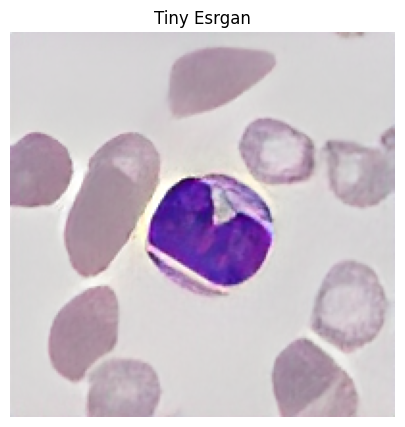

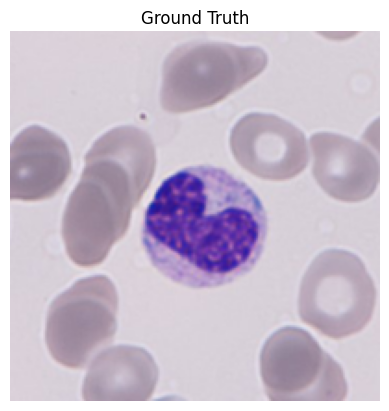

In [7]:
img_path = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset/ig/IG_102433.jpg"
img = Image.open(img_path).convert("RGB")
lr, gt = preprocess(img)

model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("Tiny Esrgan")
plt.axis("off")
plt.show()

plt.subplot()
plt.imshow(gt.permute(1,2,0))
plt.title("Ground Truth")
plt.axis("off")

plt.show()

In [8]:
from PIL import Image
import random
import torchvision.transforms.functional as TF

img_path_f = "/kaggle/input/datasets/daehoyang/flickr2k/Flickr2K/000007.png"

# Load image
img_f = Image.open(img_path_f).convert("RGB")

# Ensure image is large enough
w, h = img_f.size
if w < IMG_SIZE_HR or h < IMG_SIZE_HR:
    img_f = img_f.resize((IMG_SIZE_HR, IMG_SIZE_HR), Image.BICUBIC)
    w, h = img_f.size

# Random crop coordinates
x = 1368 # random.randint(0, w - IMG_SIZE_HR)
y = 826 # random.randint(0, h - IMG_SIZE_HR)

# Store random crop
crop_img_flicker = TF.crop(img_f, y, x, IMG_SIZE_HR, IMG_SIZE_HR)

print(crop_img_flicker.size)   # (500, 500)

(200, 200)


In [9]:
print(x,y)

1368 826


In [10]:
def preprocess_flicker(img):
    gt = img
    lr = gt.resize((IMG_SIZE_LR, IMG_SIZE_LR), Image.BICUBIC)
    lr_tensor = TF.to_tensor(lr)
    gt_tensor = TF.to_tensor(gt)

    noise = torch.randn_like(lr_tensor) * 0.001
    lr_tensor = torch.clamp(lr_tensor + noise, 0, 1)

    return lr_tensor, gt_tensor

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08258264..1.2066785].


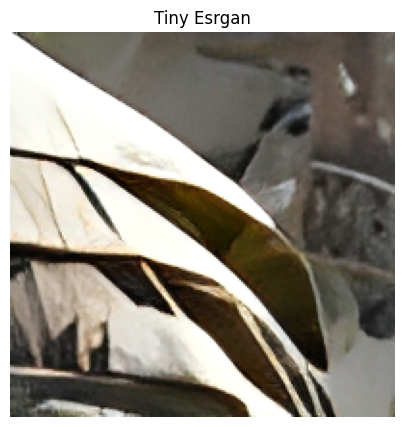

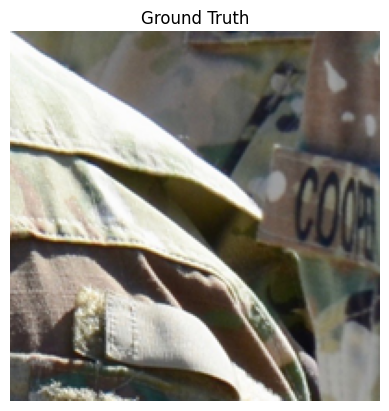

In [11]:

lr, gt = preprocess_flicker(crop_img_flicker)
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("Tiny Esrgan")
plt.axis("off")
plt.show()
plt.subplot()
plt.imshow(gt.permute(1,2,0))
plt.title("Ground Truth")
plt.axis("off")

plt.show()

In [12]:
pip install piq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 3.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [13]:
import piq

model.eval()

psnr_total = 0
ssim_total = 0
count = 0

with torch.no_grad():
    for lr, gt in test_loader:

        lr = lr.to(device)
        gt = gt.to(device)

        sr = model(lr)

        # ensure range [0,1]
        sr = torch.clamp(sr, 0, 1)

        psnr = piq.psnr(sr, gt, data_range=1.0)
        ssim = piq.ssim(sr, gt, data_range=1.0)

        psnr_total += psnr.item()
        ssim_total += ssim.item()
        count += 1

print("Average PSNR:", psnr_total / count)
print("Average SSIM:", ssim_total / count)

Average PSNR: 25.089719459493324
Average SSIM: 0.7719753895487104


In [ ]:
from PIL import Image
img_path = "/kaggle/input/datasets/daehoyang/flickr2k/Flickr2K/000001.png"
img = Image.open(img_path).convert("RGB")
lr, gt = flickr_preprocess(img)

model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(lr_up.permute(1,2,0))
plt.title("Bicubic Upscaled")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sr.permute(1,2,0))
plt.title("Tiny Esrgan")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gt.permute(1,2,0))
plt.title("Ground Truth")
plt.axis("off")

plt.show()

SAFMN


In [16]:
!pip install fvcore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=064e74ffa585856b6c1fc9326ec345d8c257b95dc6066638683315aa5b3ff384
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=059705bbbc7003d3245d01549d6c43d6d1c6129494adc4354add2a11f910c9e5
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [17]:
from fvcore.nn import flop_count_table, FlopCountAnalysis, ActivationCountAnalysis

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import ops
#from basicsr.utils.registry import ARCH_REGISTRY


# Layer Norm
class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_first"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape, )

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

# SE
class SqueezeExcitation(nn.Module):
    def __init__(self, dim, shrinkage_rate=0.25):
        super().__init__()
        hidden_dim = int(dim * shrinkage_rate)

        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(dim, hidden_dim, 1, 1, 0),
            nn.GELU(),
            nn.Conv2d(hidden_dim, dim, 1, 1, 0),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.gate(x)


# Channel MLP: Conv1*1 -> Conv1*1
class ChannelMLP(nn.Module):
    def __init__(self, dim, growth_rate=2.0):
        super().__init__()
        hidden_dim = int(dim * growth_rate)

        self.mlp = nn.Sequential(
            nn.Conv2d(dim, hidden_dim, 1, 1, 0),
            nn.GELU(),
            nn.Conv2d(hidden_dim, dim, 1, 1, 0)
        )

    def forward(self, x):
        return self.mlp(x)


# MBConv: Conv1*1 -> DW Conv3*3 -> [SE] -> Conv1*1
class MBConv(nn.Module):
    def __init__(self, dim, growth_rate=2.0):
        super().__init__()
        hidden_dim = int(dim * growth_rate)

        self.mbconv = nn.Sequential(
            nn.Conv2d(dim, hidden_dim, 1, 1, 0),
            nn.GELU(),
            nn.Conv2d(hidden_dim, hidden_dim, 3, 1, 1, groups=hidden_dim),
            nn.GELU(),
            SqueezeExcitation(hidden_dim),
            nn.Conv2d(hidden_dim, dim, 1, 1, 0)
        )

    def forward(self, x):
        return self.mbconv(x)


# CCM
class CCM(nn.Module):
    def __init__(self, dim, growth_rate=2.0):
        super().__init__()
        hidden_dim = int(dim * growth_rate)

        self.ccm = nn.Sequential(
            nn.Conv2d(dim, hidden_dim, 3, 1, 1),
            nn.GELU(), 
            nn.Conv2d(hidden_dim, dim, 1, 1, 0)
        )

    def forward(self, x):
        return self.ccm(x)


# SAFM
class SAFM(nn.Module):
    def __init__(self, dim, n_levels=4):
        super().__init__()
        self.n_levels = n_levels
        chunk_dim = dim // n_levels

        # Spatial Weighting
        self.mfr = nn.ModuleList([nn.Conv2d(chunk_dim, chunk_dim, 3, 1, 1, groups=chunk_dim) for i in range(self.n_levels)])
        
        # # Feature Aggregation
        self.aggr = nn.Conv2d(dim, dim, 1, 1, 0)
        
        # Activation
        self.act = nn.GELU() 

    def forward(self, x):
        h, w = x.size()[-2:]

        xc = x.chunk(self.n_levels, dim=1)
        out = []
        for i in range(self.n_levels):
            if i > 0:
                p_size = (h//2**i, w//2**i)
                s = F.adaptive_max_pool2d(xc[i], p_size)
                s = self.mfr[i](s)
                s = F.interpolate(s, size=(h, w), mode='nearest')
            else:
                s = self.mfr[i](xc[i])
            out.append(s)

        out = self.aggr(torch.cat(out, dim=1))
        out = self.act(out) * x
        return out

class AttBlock(nn.Module):
    def __init__(self, dim, ffn_scale=2.0):
        super().__init__()

        self.norm1 = LayerNorm(dim) 
        self.norm2 = LayerNorm(dim) 

        # Multiscale Block
        self.safm = SAFM(dim) 
        # Feedforward layer
        self.ccm = CCM(dim, ffn_scale) 

    def forward(self, x):
        x = self.safm(self.norm1(x)) + x
        x = self.ccm(self.norm2(x)) + x
        return x
        
        
#@ARCH_REGISTRY.register()
class SAFMN(nn.Module):
    def __init__(self, dim, n_blocks=8, ffn_scale=2.0, upscaling_factor=4):
        super().__init__()
        self.to_feat = nn.Conv2d(3, dim, 3, 1, 1)

        self.feats = nn.Sequential(*[AttBlock(dim, ffn_scale) for _ in range(n_blocks)])

        self.to_img = nn.Sequential(
            nn.Conv2d(dim, 3 * upscaling_factor**2, 3, 1, 1),
            nn.PixelShuffle(upscaling_factor)
        )

    def forward(self, x):
        x = self.to_feat(x)
        x = self.feats(x) + x
        x = self.to_img(x)
        return x



if __name__== '__main__':
    #############Test Model Complexity #############
    ''''''
    from fvcore.nn import flop_count_table, FlopCountAnalysis, ActivationCountAnalysis    
    # x = torch.randn(1, 3, 640, 360)
    # x = torch.randn(1, 3, 427, 240)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = torch.randn(1, 3, 960, 540).to(device)
    # x = torch.randn(1, 3, 256, 256)

    model = SAFMN(dim=64, n_blocks=10, ffn_scale=2.0, upscaling_factor=4).to(device)
    model.eval()
    # model = SAFMN(dim=36, n_blocks=12, ffn_scale=2.0, upscaling_factor=2)
    try:
        flops = FlopCountAnalysis(model, x).total()
        flops = flops / 10 ** 9
        print(f"Total GFLOPs: {flops}")
    except Exception as e:
        print(f"Error occurred while calculating FLOPs: {e}")
        if torch.cuda.is_available():
            print("Max GPU memory allocated:", torch.cuda.max_memory_allocated(0) / (1024 ** 3), "GB")
        else:
            print("CUDA is not available, cannot measure GPU memory usage.")
    print("Max GPU memory allocated:", torch.cuda.max_memory_allocated(0) / (1024 ** 3), "GB")

Error occurred while calculating FLOPs: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 110.81 MiB is free. Including non-PyTorch memory, this process has 14.45 GiB memory in use. Of the allocated memory 14.18 GiB is allocated by PyTorch, and 160.54 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
Max GPU memory allocated: 14.175249576568604 GB
Max GPU memory allocated: 14.175249576568604 GB


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SAFMN(
    dim=96,
    n_blocks=16,
    ffn_scale=2.0,
    upscaling_factor=4
).to(device)

MODEL_PATH = "/kaggle/input/models/msugandha/safmn/other/default/1/safmn-L.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["params"])

model.eval()

print("Model loaded successfully")

Model loaded successfully


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006604828..1.1225972].


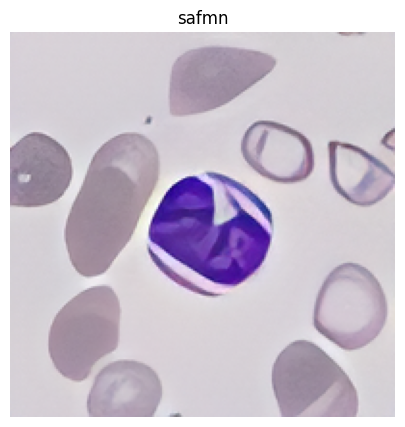

In [20]:


img_path = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset/ig/IG_102433.jpg"
img = Image.open(img_path).convert("RGB")
lr, gt = preprocess(img)

model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("safmn")
plt.axis("off")

# plt.subplot(1,3,3)
# plt.imshow(gt.permute(1,2,0))
# plt.title("Ground Truth")
# plt.axis("off")

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11327973..1.2234235].


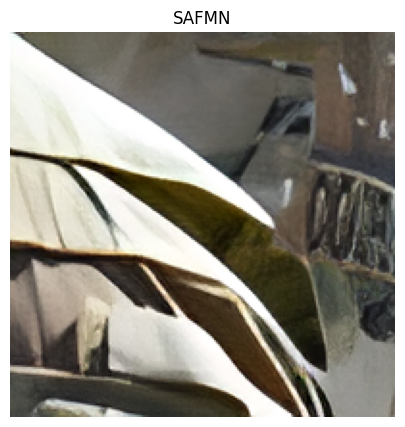

In [21]:



lr, gt = preprocess(crop_img_flicker)
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("SAFMN")
plt.axis("off")
plt.show()


plt.show()

In [22]:
import piq

model.eval()

psnr_total = 0
ssim_total = 0
count = 0

with torch.no_grad():
    for lr, gt in test_loader:

        lr = lr.to(device)
        gt = gt.to(device)

        sr = model(lr)

        # ensure range [0,1]
        sr = torch.clamp(sr, 0, 1)

        psnr = piq.psnr(sr, gt, data_range=1.0)
        ssim = piq.ssim(sr, gt, data_range=1.0)

        psnr_total += psnr.item()
        ssim_total += ssim.item()
        count += 1

print("Average PSNR:", psnr_total / count)
print("Average SSIM:", ssim_total / count)

Average PSNR: 26.13431682788506
Average SSIM: 0.8066615224199951


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def multiscale(kernel, target_kernel_size):
    H_pixels_to_pad = (target_kernel_size - kernel.size(2)) // 2
    W_pixels_to_pad = (target_kernel_size - kernel.size(3)) // 2
    return F.pad(kernel, [H_pixels_to_pad, H_pixels_to_pad, W_pixels_to_pad, W_pixels_to_pad])

class SeqConv3x3(nn.Module):
    def __init__(self, seq_type, inp_planes, out_planes, depth_multiplier):
        super(SeqConv3x3, self).__init__()

        self.type = seq_type
        self.inp_planes = inp_planes
        self.out_planes = out_planes

        if self.type == 'conv1x1-conv3x3':
            self.mid_planes = int(out_planes * depth_multiplier)
            conv0 = torch.nn.Conv2d(self.inp_planes, self.mid_planes, kernel_size=1, padding=0)
            self.k0 = conv0.weight
            self.b0 = conv0.bias

            conv1 = torch.nn.Conv2d(self.mid_planes, self.out_planes, kernel_size=3)
            self.k1 = conv1.weight
            self.b1 = conv1.bias
            
        elif self.type == 'conv1x1-sobelx':
            conv0 = torch.nn.Conv2d(self.inp_planes, self.out_planes, kernel_size=1, padding=0)
            self.k0 = conv0.weight
            self.b0 = conv0.bias

            # init scale & bias
            scale = torch.randn(size=(self.out_planes, 1, 1, 1)) * 1e-3
            self.scale = nn.Parameter(scale)
            # bias = 0.0
            # bias = [bias for c in range(self.out_planes)]
            # bias = torch.FloatTensor(bias)
            bias = torch.randn(self.out_planes) * 1e-3
            bias = torch.reshape(bias, (self.out_planes,))
            self.bias = nn.Parameter(bias)
            # init mask
            self.mask = torch.zeros((self.out_planes, 1, 3, 3), dtype=torch.float32)
            for i in range(self.out_planes):
                self.mask[i, 0, 0, 0] = 1.0
                self.mask[i, 0, 1, 0] = 2.0
                self.mask[i, 0, 2, 0] = 1.0
                self.mask[i, 0, 0, 2] = -1.0
                self.mask[i, 0, 1, 2] = -2.0
                self.mask[i, 0, 2, 2] = -1.0
            self.mask = nn.Parameter(data=self.mask, requires_grad=False)

        elif self.type == 'conv1x1-sobely':
            conv0 = torch.nn.Conv2d(self.inp_planes, self.out_planes, kernel_size=1, padding=0)
            self.k0 = conv0.weight
            self.b0 = conv0.bias

            # init scale & bias
            scale = torch.randn(size=(self.out_planes, 1, 1, 1)) * 1e-3
            self.scale = nn.Parameter(torch.FloatTensor(scale))
            # bias = 0.0
            # bias = [bias for c in range(self.out_planes)]
            # bias = torch.FloatTensor(bias)
            bias = torch.randn(self.out_planes) * 1e-3
            bias = torch.reshape(bias, (self.out_planes,))
            self.bias = nn.Parameter(torch.FloatTensor(bias))
            # init mask
            self.mask = torch.zeros((self.out_planes, 1, 3, 3), dtype=torch.float32)
            for i in range(self.out_planes):
                self.mask[i, 0, 0, 0] = 1.0
                self.mask[i, 0, 0, 1] = 2.0
                self.mask[i, 0, 0, 2] = 1.0
                self.mask[i, 0, 2, 0] = -1.0
                self.mask[i, 0, 2, 1] = -2.0
                self.mask[i, 0, 2, 2] = -1.0
            self.mask = nn.Parameter(data=self.mask, requires_grad=False)

        elif self.type == 'conv1x1-laplacian':
            conv0 = torch.nn.Conv2d(self.inp_planes, self.out_planes, kernel_size=1, padding=0)
            self.k0 = conv0.weight
            self.b0 = conv0.bias

            # init scale & bias
            scale = torch.randn(size=(self.out_planes, 1, 1, 1)) * 1e-3
            self.scale = nn.Parameter(torch.FloatTensor(scale))
            # bias = 0.0
            # bias = [bias for c in range(self.out_planes)]
            # bias = torch.FloatTensor(bias)
            bias = torch.randn(self.out_planes) * 1e-3
            bias = torch.reshape(bias, (self.out_planes,))
            self.bias = nn.Parameter(torch.FloatTensor(bias))
            # init mask
            self.mask = torch.zeros((self.out_planes, 1, 3, 3), dtype=torch.float32)
            for i in range(self.out_planes):
                self.mask[i, 0, 0, 1] = 1.0
                self.mask[i, 0, 1, 0] = 1.0
                self.mask[i, 0, 1, 2] = 1.0
                self.mask[i, 0, 2, 1] = 1.0
                self.mask[i, 0, 1, 1] = -4.0
            self.mask = nn.Parameter(data=self.mask, requires_grad=False)
        else:
            raise ValueError('the type of seqconv is not supported!')

    def forward(self, x):
        if self.type == 'conv1x1-conv3x3':
            # conv-1x1
            y0 = F.conv2d(input=x, weight=self.k0, bias=self.b0, stride=1)
            # explicitly padding with bias
            y0 = F.pad(y0, (1, 1, 1, 1), 'constant', 0)
            b0_pad = self.b0.view(1, -1, 1, 1)
            y0[:, :, 0:1, :] = b0_pad
            y0[:, :, -1:, :] = b0_pad
            y0[:, :, :, 0:1] = b0_pad
            y0[:, :, :, -1:] = b0_pad
            # conv-3x3
            y1 = F.conv2d(input=y0, weight=self.k1, bias=self.b1, stride=1)
        else:
            y0 = F.conv2d(input=x, weight=self.k0, bias=self.b0, stride=1)
            # explicitly padding with bias
            y0 = F.pad(y0, (1, 1, 1, 1), 'constant', 0)
            b0_pad = self.b0.view(1, -1, 1, 1)
            y0[:, :, 0:1, :] = b0_pad
            y0[:, :, -1:, :] = b0_pad
            y0[:, :, :, 0:1] = b0_pad
            y0[:, :, :, -1:] = b0_pad
            # conv-3x3
            y1 = F.conv2d(input=y0, weight=self.scale * self.mask, bias=self.bias, stride=1, groups=self.out_planes)
        return y1
    
    def rep_params(self):
        device = self.k0.get_device()
        if device < 0:
            device = None

        if self.type == 'conv1x1-conv3x3':
            # re-param conv kernel
            RK = F.conv2d(input=self.k1, weight=self.k0.permute(1, 0, 2, 3))
            # re-param conv bias
            RB = torch.ones(1, self.mid_planes, 3, 3, device=device) * self.b0.view(1, -1, 1, 1)
            RB = F.conv2d(input=RB, weight=self.k1).view(-1,) + self.b1
        else:
            tmp = self.scale * self.mask
            k1 = torch.zeros((self.out_planes, self.out_planes, 3, 3), device=device)
            for i in range(self.out_planes):
                k1[i, i, :, :] = tmp[i, 0, :, :]
            b1 = self.bias
            # re-param conv kernel
            RK = F.conv2d(input=k1, weight=self.k0.permute(1, 0, 2, 3))
            # re-param conv bias
            RB = torch.ones(1, self.out_planes, 3, 3, device=device) * self.b0.view(1, -1, 1, 1)
            RB = F.conv2d(input=RB, weight=k1).view(-1,) + b1
        return RK, RB



class EDBB(nn.Module):
    def __init__(self, inp_planes, out_planes, depth_multiplier=None, act_type='prelu', with_idt = False, deploy=False, with_13=False, gv=False):
        super(EDBB, self).__init__()
        
        self.deploy = deploy
        self.act_type = act_type
        
        self.inp_planes = inp_planes
        self.out_planes = out_planes

        self.gv = gv          

        if depth_multiplier is None:
            self.depth_multiplier = 1.0
        else: 
            self.depth_multiplier = depth_multiplier   # For mobilenet, it is better to have 2X internal channels
        
        if deploy:
            self.rep_conv = nn.Conv2d(in_channels=inp_planes, out_channels=out_planes, kernel_size=3, stride=1,
                                      padding=1, bias=True)
        else: 
            self.with_13 = with_13
            if with_idt and (self.inp_planes == self.out_planes):
                self.with_idt = True
            else:
                self.with_idt = False

            self.rep_conv = nn.Conv2d(self.inp_planes, self.out_planes, kernel_size=3, padding=1)
            self.conv1x1 = nn.Conv2d(self.inp_planes, self.out_planes, kernel_size=1, padding=0)
            self.conv1x1_3x3 = SeqConv3x3('conv1x1-conv3x3', self.inp_planes, self.out_planes, self.depth_multiplier)
            self.conv1x1_sbx = SeqConv3x3('conv1x1-sobelx', self.inp_planes, self.out_planes, -1)
            self.conv1x1_sby = SeqConv3x3('conv1x1-sobely', self.inp_planes, self.out_planes, -1)
            self.conv1x1_lpl = SeqConv3x3('conv1x1-laplacian', self.inp_planes, self.out_planes, -1)

        if self.act_type == 'prelu':
            self.act = nn.PReLU(num_parameters=self.out_planes)
        elif self.act_type == 'relu':
            self.act = nn.ReLU(inplace=True)
        elif self.act_type == 'rrelu':
            self.act = nn.RReLU(lower=-0.05, upper=0.05)
        elif self.act_type == 'softplus':
            self.act = nn.Softplus()
        elif self.act_type == 'linear':
            pass
        else:
            raise ValueError('The type of activation if not support!')

    def forward(self, x):
        if self.deploy:
            y = self.rep_conv(x)
        elif self.gv:
            y = self.rep_conv(x)     + \
                self.conv1x1_sbx(x) + \
                self.conv1x1_sby(x) + \
                self.conv1x1_lpl(x) + x 
        else:
            y = self.rep_conv(x)     + \
                self.conv1x1(x)     + \
                self.conv1x1_sbx(x) + \
                self.conv1x1_sby(x) + \
                self.conv1x1_lpl(x)            
                #self.conv1x1_3x3(x) + \
            if self.with_idt:
                y += x
            if self.with_13:
                y += self.conv1x1_3x3(x)

        if self.act_type != 'linear':
            y = self.act(y)
        return y
    
    def switch_to_gv(self):
        if self.gv:
            return
        self.gv = True
        
        K0, B0 = self.rep_conv.weight, self.rep_conv.bias
        K1, B1 = self.conv1x1_3x3.rep_params()
        K5, B5 = multiscale(self.conv1x1.weight,3), self.conv1x1.bias
        RK, RB = (K0+K5), (B0+B5) 
        if self.with_13:
            RK, RB = RK + K1, RB + B1

        self.rep_conv.weight.data = RK
        self.rep_conv.bias.data = RB
        
        for para in self.parameters():
            para.detach_()
      
    
    def switch_to_deploy(self):

        if self.deploy:
            return
        self.deploy = True
        
        K0, B0 = self.rep_conv.weight, self.rep_conv.bias
        K1, B1 = self.conv1x1_3x3.rep_params()
        K2, B2 = self.conv1x1_sbx.rep_params()
        K3, B3 = self.conv1x1_sby.rep_params()
        K4, B4 = self.conv1x1_lpl.rep_params()
        K5, B5 = multiscale(self.conv1x1.weight,3), self.conv1x1.bias
        if self.gv:
            RK, RB = (K0+K2+K3+K4), (B0+B2+B3+B4) 
        else:
            RK, RB = (K0+K2+K3+K4+K5), (B0+B2+B3+B4+B5) 
            if self.with_13:
                RK, RB = RK + K1, RB + B1
        if self.with_idt:
            device = RK.get_device()
            if device < 0:
                device = None
            K_idt = torch.zeros(self.out_planes, self.out_planes, 3, 3, device=device)
            for i in range(self.out_planes):
                K_idt[i, i, 1, 1] = 1.0
            B_idt = 0.0
            RK, RB = RK + K_idt, RB + B_idt        
            

        self.rep_conv = nn.Conv2d(in_channels=self.inp_planes, out_channels=self.out_planes, kernel_size=3, stride=1,
                                      padding=1, bias=True)
        self.rep_conv.weight.data = RK
        self.rep_conv.bias.data = RB
        
        for para in self.parameters():
            para.detach_()
            
        #self.__delattr__('conv3x3')
        self.__delattr__('conv1x1_3x3')
        self.__delattr__('conv1x1')
        self.__delattr__('conv1x1_sbx')
        self.__delattr__('conv1x1_sby')
        self.__delattr__('conv1x1_lpl')

class EDBB_deploy(nn.Module):
    def __init__(self, inp_planes, out_planes):
        super(EDBB_deploy, self).__init__()
               
        self.rep_conv = nn.Conv2d(in_channels=inp_planes, out_channels=out_planes, kernel_size=3, stride=1,
                                      padding=1, bias=True)
 
        self.act = nn.PReLU(num_parameters=out_planes)

    def forward(self, x):
        y = self.rep_conv(x)
        y = self.act(y)
        
        return y


class ESA(nn.Module):
    def __init__(self, n_feats, conv):
        super(ESA, self).__init__()
        f = n_feats // 4
        self.conv1 = conv(n_feats, f, kernel_size=1)
        self.conv_f = conv(f, f, kernel_size=1)
        self.conv_max = conv(f, f, kernel_size=3, padding=1)
        self.conv2 = conv(f, f, kernel_size=3, stride=2, padding=0)
        self.conv3 = conv(f, f, kernel_size=3, padding=1)
        self.conv3_ = conv(f, f, kernel_size=3, padding=1)
        self.conv4 = conv(f, n_feats, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        c1_ = (self.conv1(x))
        c1 = self.conv2(c1_)
        v_max = F.max_pool2d(c1, kernel_size=7, stride=3)
        v_range = self.relu(self.conv_max(v_max))
        c3 = self.relu(self.conv3(v_range))
        c3 = self.conv3_(c3)
        c3 = F.interpolate(c3, (x.size(2), x.size(3)), mode='bilinear', align_corners=False) 
        cf = self.conv_f(c1_)
        c4 = self.conv4(c3+cf)
        m = self.sigmoid(c4)

        return x * m

          
class conv(nn.Module):
    def __init__(self, n_feats):
        super(conv, self).__init__()
        self.conv1x1 = nn.Conv2d(n_feats, n_feats, 1, 1, 0) 
        self.act = nn.PReLU(num_parameters=n_feats)
    def forward(self, x):
        return self.act(self.conv1x1(x))
    
class Cell(nn.Module):
    def __init__(self, n_feats=48, dynamic = True, deploy = False, L= None, with_13=False):
        super(Cell, self).__init__()
        
        self.conv1 = conv(n_feats)#nn.Conv2d(n_feats, n_feats, 1, 1, 0) 
        self.conv2 = EDBB_deploy(n_feats,n_feats)
        self.conv3 = EDBB_deploy(n_feats,n_feats)

        self.fuse = nn.Conv2d(n_feats*2, n_feats, 1, 1, 0)

        self.att = ESA(n_feats, nn.Conv2d) #MAB(n_feats)# ENLCA(n_feats)  #CoordAtt(n_feats,n_feats,10)# 

        self.branch = nn.ModuleList([nn.Conv2d(n_feats, n_feats//2, 1, 1, 0) for _ in range(4)])

    def forward(self, x):
        out1 = self.conv1(x)
        out2 = self.conv2(out1)
        out3 = self.conv3(out2)

        # fuse [x, out1, out2, out3]
        out = self.fuse(torch.cat([self.branch[0](x), self.branch[1](out1), self.branch[2](out2), self.branch[3](out3)], dim=1))
        out = self.att(out)
        out += x

        return out


class EFDN(nn.Module):
    def __init__(self, scale=4, in_channels=3, n_feats=48, out_channels=3):
        super(EFDN, self).__init__()
        self.head = nn.Conv2d(in_channels, n_feats, 3, 1, 1)
        # body cells
        self.cells = nn.ModuleList([Cell(n_feats) for _ in range(4)])
        
        # fusion
        self.local_fuse = nn.ModuleList([nn.Conv2d(n_feats*2, n_feats, 1, 1, 0) for _ in range(3)])

        self.tail = nn.Sequential(
            nn.Conv2d(n_feats, out_channels*(scale**2), 3, 1, 1),
            nn.PixelShuffle(scale)
        )

    def forward(self, x):
        # head
        out0 = self.head(x)

        # body cells
        out1 = self.cells[0](out0)
        out2 = self.cells[1](out1)
        out2_fuse = self.local_fuse[0](torch.cat([out1, out2], dim=1))
        out3 = self.cells[2](out2_fuse)
        out3_fuse = self.local_fuse[1](torch.cat([out2, out3], dim=1))
        out4 = self.cells[3](out3_fuse)
        out4_fuse = self.local_fuse[2](torch.cat([out2, out4], dim=1))

        out = out4_fuse + out0      

        # tail
        out = self.tail(out)

        return out.clamp(0,1)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EFDN(
    scale=4,
    in_channels=3,
    n_feats=48,
    out_channels=3
).to(device)

MODEL_PATH = "/kaggle/input/models/msugandha/efdn/other/default/1/efdn.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint)

model.eval()

print("Model loaded successfully")

Model loaded successfully


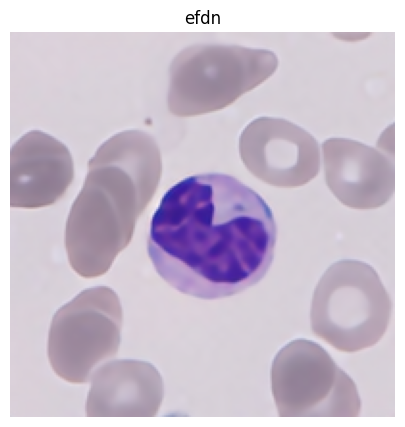

In [25]:


img_path = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset/ig/IG_102433.jpg"
img = Image.open(img_path).convert("RGB")
lr, gt = preprocess(img)

model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("efdn")
plt.axis("off")

# plt.subplot(1,3,3)
# plt.imshow(gt.permute(1,2,0))
# plt.title("Ground Truth")
# plt.axis("off")

plt.show()

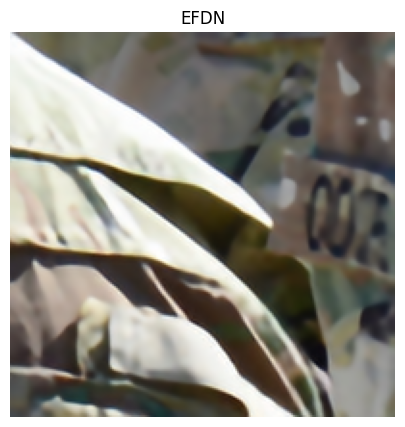

In [26]:



lr, gt = preprocess(crop_img_flicker)
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("EFDN")
plt.axis("off")
plt.show()


plt.show()

In [27]:
import piq

model.eval()

psnr_total = 0
ssim_total = 0
count = 0

with torch.no_grad():
    for lr, gt in test_loader:

        lr = lr.to(device)
        gt = gt.to(device)

        sr = model(lr)

        # ensure range [0,1]
        sr = torch.clamp(sr, 0, 1)

        psnr = piq.psnr(sr, gt, data_range=1.0)
        ssim = piq.ssim(sr, gt, data_range=1.0)

        psnr_total += psnr.item()
        ssim_total += ssim.item()
        count += 1

print("Average PSNR:", psnr_total / count)
print("Average SSIM:", ssim_total / count)

Average PSNR: 35.0354150565213
Average SSIM: 0.9457518529324305


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary


class ResidualDenseBlock(nn.Module):
    def __init__(self, channels, growth_rate=32):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, growth_rate, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_rate, channels, 3, padding=1)

        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.conv2(torch.cat((x, x1), 1))

        return x2 * 0.2 + x


class ZoomSR10x(nn.Module):
    def __init__(self, upscale_factor=10, channels=3):
        super().__init__()

        self.upscale_factor = upscale_factor

        # Feature extraction
        self.head = nn.Conv2d(channels, 64, kernel_size=3, padding=1)

        # 🔥 More Residual Dense Blocks (3 → 8)
        self.body = nn.Sequential(
            *[ResidualDenseBlock(64) for _ in range(8)]
        )

        # 🔥 Extra conv layer after body
        self.trunk_conv = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # Reconstruction
        self.reconstruction = nn.Conv2d(64, channels, kernel_size=3, padding=1)
        # 🔥 NEW: refinement after upscaling
        self.refine = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 3, 3, padding=1)
        )


    def forward(self, x):

        base = F.interpolate(
            x,
            scale_factor=self.upscale_factor,
            mode='bicubic',
            align_corners=False
        )
    
        fea = self.head(x)
        res = self.body(fea)
        res = self.trunk_conv(res)
        out_lr = self.reconstruction(res)
    
        out_hr = F.interpolate(
            out_lr,
            scale_factor=self.upscale_factor,
            mode='bicubic',
            align_corners=False
        )
    
          # 🔥 Residual learning
        out = out_hr + base

        # 🔥 Refinement
        out = self.refine(out)

        return torch.clamp(out, 0, 1)


# Create model
model = ZoomSR10x(upscale_factor=10)

print(model)
summary(model, input_size=(1,3,50,50))

ZoomSR10x(
  (head): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): ResidualDenseBlock(
      (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): ResidualDenseBlock(
      (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): ResidualDenseBlock(
      (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): ResidualDenseBlock(
      (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2):

Layer (type:depth-idx)                   Output Shape              Param #
ZoomSR10x                                [1, 3, 500, 500]          --
├─Conv2d: 1-1                            [1, 64, 50, 50]           1,792
├─Sequential: 1-2                        [1, 64, 50, 50]           --
│    └─ResidualDenseBlock: 2-1           [1, 64, 50, 50]           --
│    │    └─Conv2d: 3-1                  [1, 32, 50, 50]           18,464
│    │    └─LeakyReLU: 3-2               [1, 32, 50, 50]           --
│    │    └─Conv2d: 3-3                  [1, 64, 50, 50]           55,360
│    └─ResidualDenseBlock: 2-2           [1, 64, 50, 50]           --
│    │    └─Conv2d: 3-4                  [1, 32, 50, 50]           18,464
│    │    └─LeakyReLU: 3-5               [1, 32, 50, 50]           --
│    │    └─Conv2d: 3-6                  [1, 64, 50, 50]           55,360
│    └─ResidualDenseBlock: 2-3           [1, 64, 50, 50]           --
│    │    └─Conv2d: 3-7                  [1, 32, 50, 50]          

In [11]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 634566


In [12]:
def edge_loss(pred, gt):
    # Horizontal edges
    pred_dx = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
    gt_dx   = torch.abs(gt[:, :, :, 1:] - gt[:, :, :, :-1])
    loss_dx = torch.mean(torch.abs(pred_dx - gt_dx))

    # Vertical edges
    pred_dy = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
    gt_dy   = torch.abs(gt[:, :, 1:, :] - gt[:, :, :-1, :])
    loss_dy = torch.mean(torch.abs(pred_dy - gt_dy))

    return loss_dx + loss_dy

In [13]:
def sobel_edges(x):
    sobel_x = torch.tensor([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=torch.float32, device=x.device)

    sobel_y = torch.tensor([[1, 2, 1],
                            [0, 0, 0],
                            [-1, -2, -1]], dtype=torch.float32, device=x.device)

    sobel_x = sobel_x.view(1, 1, 3, 3)
    sobel_y = sobel_y.view(1, 1, 3, 3)

    # convert to grayscale
    x_gray = x.mean(dim=1, keepdim=True)

    grad_x = F.conv2d(x_gray, sobel_x, padding=1)
    grad_y = F.conv2d(x_gray, sobel_y, padding=1)

    edges = torch.sqrt(grad_x**2 + grad_y**2 + 1e-6)

    return edges

In [14]:
def smooth_loss(x):
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1])
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :])
    return dx.mean() + dy.mean()

In [15]:
model = ZoomSR10x(upscale_factor=10).to(device)
optimizer = optim.Adam(model.parameters(),lr = 3e-5)


criterion = nn.MSELoss(reduction='none')

def train_epoch(model, loader):

    model.train()
    total_loss = 0

    for lr, gt in loader:

        lr = lr.to(device)
        gt = gt.to(device)

        optimizer.zero_grad()

        out = model(lr)

        gt_lr = F.interpolate(
            gt,
            size=(50,50),
            mode='bicubic',
            align_corners=False
        )

        # 🔥 Sobel edge maps
        out_edges = sobel_edges(out)
        gt_edges = sobel_edges(gt)


        # 🔥 NEW MSE on edges
        mse = criterion(out_edges, gt_edges).mean()

        edge = edge_loss(out, gt)   
        out_blur = F.avg_pool2d(out, 5, stride=1, padding=2)
        loss = 0.4 * mse + 0.2 * edge + 0.3 * F.l1_loss(out, gt) + 0.1 * smooth_loss(out)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        # xm.mark_step()   # ⭐ REQUIRED FOR TPU

        total_loss += loss.item()

    return total_loss / len(loader)

In [16]:
FINAL_MODEL_PATH = "/kaggle/input/models/msugandha/model3/other/default/1/ResidualDenseBlock8_25epochs-mse0.4_sobeledge0.2l10.3smooth0.1 (1).pth"
    
# torch.save(model.state_dict(), FINAL_MODEL_PATH)
# print("Final model saved at:", FINAL_MODEL_PATH)

In [ ]:
# model = EncoderDecoderSR().to(device)
model = ZoomSR10x(upscale_factor=10).to(device)

state_dict = torch.load(FINAL_MODEL_PATH, map_location="cpu")

model.load_state_dict(state_dict)

model = model.to(device)

model.eval()

lr, gt = preprocess(crop_img_flicker)
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
# plt.title("RDN + sobel + without erosion")
plt.axis("off")
plt.show()
# plt.subplot()
# plt.imshow(gt.permute(1,2,0))
# plt.title("Ground Truth")
# plt.axis("off")

# plt.show()

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        res = self.relu(self.conv1(x))
        res = self.conv2(res)
        return x + 0.1 * res

In [8]:
class ResidualSRNet(nn.Module):
    def __init__(self, num_blocks=4, upscale_factor=10):
        super().__init__()

        self.head = nn.Conv2d(3, 64, 3, padding=1)
        self.body = nn.Sequential(*[ResidualBlock(64) for _ in range(num_blocks)])

        self.upsample_conv = nn.Conv2d(64, 3 * (upscale_factor ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)

    def forward(self, x):
        base = F.interpolate(
            x,
            scale_factor=self.pixel_shuffle.upscale_factor,
            mode='bicubic',
            align_corners=False
        )

        fea = self.head(x)
        fea = self.body(fea)

        out = self.upsample_conv(fea)
        out = self.pixel_shuffle(out)

        refined = out + base

        return torch.clamp(refined, 0, 1)

In [9]:
import cv2

def canny_edge(tensor):
    edges = []
    for img in tensor:
        img_np = img.detach().permute(1,2,0).cpu().numpy()

        img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8),
                                cv2.COLOR_RGB2GRAY)

        edge = cv2.Canny(img_gray, 100, 200)

        edge = torch.tensor(edge / 255.0, dtype=torch.float32)
        edges.append(edge.unsqueeze(0))

    return torch.stack(edges).to(tensor.device)


def canny_edge_loss(pred, gt):
    with torch.no_grad():
        pred_edge = canny_edge(pred)
        gt_edge   = canny_edge(gt)

    return F.l1_loss(pred_edge, gt_edge)

In [10]:
def total_loss(pred, gt):
    l1 = F.l1_loss(pred, gt)
    edge = canny_edge_loss(pred, gt)
    return l1 + 0.1 * edge

In [11]:
FINAL_MODEL_PATH = "/kaggle/input/models/msugandha/model4/other/default/1/ResidualSRNet_CannyOnly.pth"
model = ResidualSRNet(num_blocks=4, upscale_factor=10).to(device)

state_dict = torch.load(FINAL_MODEL_PATH, map_location=device)

model.load_state_dict(state_dict)

model.eval()

ResidualSRNet(
  (head): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, ker

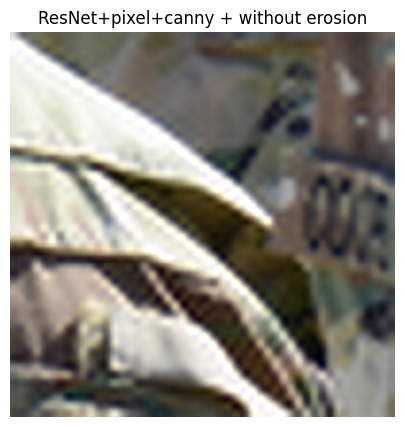

In [12]:



lr, gt = preprocess(crop_img_flicker)
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("ResNet+pixel+canny + without erosion")
plt.axis("off")
plt.show()


plt.show()

In [18]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        res = self.relu(self.conv1(x))
        res = self.conv2(res)
        return x + 0.1 * res

class ErosionLayer(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.pad = kernel_size // 2
        self.kernel_size = kernel_size

    def forward(self, x):
        return -F.max_pool2d(-x, kernel_size=self.kernel_size, stride=1, padding=self.pad)

In [19]:
class ResidualSRNet(nn.Module):
    def __init__(self, num_blocks=4, upscale_factor=10):
        super().__init__()

        self.head = nn.Conv2d(3, 64, 3, padding=1)

        self.body = nn.Sequential(*[ResidualBlock(64) for _ in range(num_blocks)])
        self.upsample_conv = nn.Conv2d(64, 3 * (upscale_factor ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)

        # Erosion layer
        self.erosion = ErosionLayer(kernel_size=3)

    def forward(self, x):
        base = F.interpolate(x, scale_factor=self.pixel_shuffle.upscale_factor, mode='bicubic', align_corners=False)
        fea = self.head(x)
        fea = self.body(fea)
        out = self.upsample_conv(fea)
        out = self.pixel_shuffle(out)

        refined = out + base
        eroded = self.erosion(refined)
        final = 0.7 * refined + 0.3 * eroded

        return torch.clamp(final, 0, 1)

In [20]:
def sobel_edge_loss(pred, gt):
    pred_gray = pred.mean(dim=1, keepdim=True)
    gt_gray   = gt.mean(dim=1, keepdim=True)

    sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32, device=pred.device).view(1,1,3,3)
    sobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32, device=pred.device).view(1,1,3,3)

    pred_x = F.conv2d(pred_gray, sobel_x, padding=1)
    pred_y = F.conv2d(pred_gray, sobel_y, padding=1)

    gt_x = F.conv2d(gt_gray, sobel_x, padding=1)
    gt_y = F.conv2d(gt_gray, sobel_y, padding=1)

    pred_edge = torch.sqrt(pred_x**2 + pred_y**2 + 1e-6)
    gt_edge   = torch.sqrt(gt_x**2 + gt_y**2 + 1e-6)

    return F.l1_loss(pred_edge, gt_edge)

def total_loss(pred, gt):
    l1 = F.l1_loss(pred, gt)
    edge = sobel_edge_loss(pred, gt)
    return l1 + 0.1 * edge

In [21]:
FINAL_MODEL_PATH = "/kaggle/input/models/msugandha/sobelerosion/other/default/1/ResidualSRNet1_SobelErosion.pth"
model = ResidualSRNet(num_blocks=4, upscale_factor=10).to(device)

state_dict = torch.load(FINAL_MODEL_PATH, map_location=device)

model.load_state_dict(state_dict)

model.eval()

ResidualSRNet(
  (head): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, ker

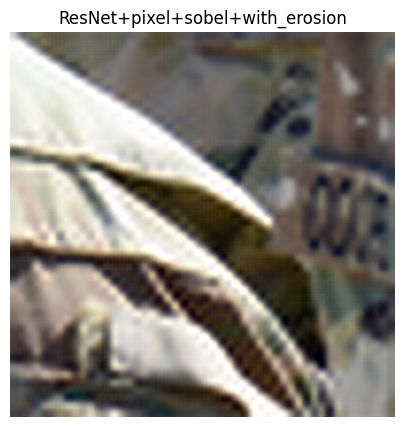

In [13]:



lr, gt = preprocess(crop_img_flicker)
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("ResNet+pixel+sobel+with_erosion")
plt.axis("off")
plt.show()


plt.show()

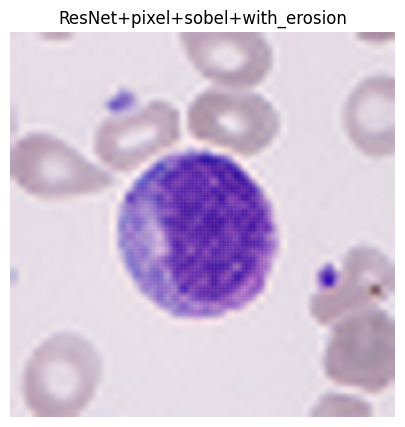

In [23]:


img_path = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset/ig/IG_101958.jpg"
img = Image.open(img_path).convert("RGB")
lr, gt = preprocess(img)

model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

lr_up = F.interpolate(lr.unsqueeze(0), size=(IMG_SIZE_HR, IMG_SIZE_HR), mode='bicubic').squeeze(0)

plt.figure(figsize=(15,5))

# plt.subplot(1,3,1)
# plt.imshow(lr_up.permute(1,2,0))
# plt.title("Bicubic Upscaled")
# plt.axis("off")

plt.subplot()
plt.imshow(sr.permute(1,2,0))
plt.title("ResNet+pixel+sobel+with_erosion")
plt.axis("off")

# plt.subplot(1,3,3)
# plt.imshow(gt.permute(1,2,0))
# plt.title("Ground Truth")
# plt.axis("off")

plt.show()